## First Graph: Building the Graph

### Set the OpenAI API Key as an Environment Variable

In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

### Import Relevant Classes and Functions

In [2]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

### Define the State

In [3]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [4]:
state = State(messages = [HumanMessage("Who is the greatest football (soccer) player of all time?")])

In [5]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Who is the greatest football (soccer) player of all time?


### Define the Nodes

In [6]:
chat = ChatOpenAI(model = "gpt-4o-mini", 
                  seed = 365, 
                  temperature = 0, 
                  max_completion_tokens = 100)

In [7]:
response = chat.invoke(state["messages"])

In [8]:
response.pretty_print()

================================== Ai Message ==================================

The title of the greatest football (soccer) player of all time is highly subjective and often debated among fans, analysts, and players. Some of the most commonly mentioned names include:

1. **Pelé** - The Brazilian forward is known for his incredible goal-scoring ability and won three FIFA World Cups (1958, 1962, 1970).
2. **Diego Maradona** - The Argentine legend is celebrated for his extraordinary skill and creativity, particularly during the 198


In [9]:
def chatbot(state: State) -> State:
    
    print(f"\n-------> ENTERING chatbot:")
    
    response = chat.invoke(state["messages"])
    response.pretty_print()
    
    return State(messages = [response])

In [10]:
chatbot(state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

The title of the greatest football (soccer) player of all time is highly subjective and often debated among fans, analysts, and players. Some of the most commonly mentioned names include:

1. **Pelé** - The Brazilian forward is known for his incredible goal-scoring ability and won three FIFA World Cups (1958, 1962, 1970).
2. **Diego Maradona** - The Argentine legend is celebrated for his extraordinary skill and creativity, particularly during the 198


{'messages': [AIMessage(content='The title of the greatest football (soccer) player of all time is highly subjective and often debated among fans, analysts, and players. Some of the most commonly mentioned names include:\n\n1. **Pelé** - The Brazilian forward is known for his incredible goal-scoring ability and won three FIFA World Cups (1958, 1962, 1970).\n2. **Diego Maradona** - The Argentine legend is celebrated for his extraordinary skill and creativity, particularly during the 198', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 21, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1590f93f9d', 'id': 'chatcmpl-D598oy5iXOhwnKzFkg4xSOUxVs8pc', 'service_tier': 'default', 'finish

### Define the Graph

In [11]:
graph = StateGraph(State)

In [12]:
graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [13]:
graph_compiled = graph.compile()

In [16]:
isinstance(graph, Runnable)

False

In [17]:
isinstance(graph_compiled, Runnable)

True

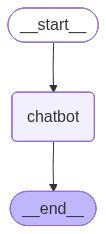

In [18]:
graph_compiled

### Test the Graph

In [19]:
graph_compiled.invoke(state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

The title of the greatest football (soccer) player of all time is highly subjective and often debated among fans, analysts, and players. Some of the most commonly mentioned names include:

1. **Pelé** - The Brazilian forward is known for his incredible goal-scoring ability and won three FIFA World Cups (1958, 1962, 1970).
2. **Diego Maradona** - The Argentine legend is celebrated for his extraordinary skill and creativity, particularly during the 198


{'messages': [AIMessage(content='The title of the greatest football (soccer) player of all time is highly subjective and often debated among fans, analysts, and players. Some of the most commonly mentioned names include:\n\n1. **Pelé** - The Brazilian forward is known for his incredible goal-scoring ability and won three FIFA World Cups (1958, 1962, 1970).\n2. **Diego Maradona** - The Argentine legend is celebrated for his extraordinary skill and creativity, particularly during the 198', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 21, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1590f93f9d', 'id': 'chatcmpl-D59Ab7NdGMMTPOU7qR3GDsXFKhsXz', 'service_tier': 'default', 'finish

In [20]:
%mypy

Success: no issues found in 1 source file
Type checking successful
